# PSD — Respiratory Virus Hub (weekly cases)

Same approach as the raw trolley PSD in `May_Presentation/slide_plots.ipynb`:
linear-detrended periodogram, `fs=1.0` (weekly), x-axis in weeks per cycle.

Data: `supplementary data/Respiratory_Virus_Hub_Open_Data.csv` — weekly cases for Influenza, RSV, COVID-19.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from statsmodels.graphics.tsaplots import plot_acf

In [48]:
df = pd.read_csv("../supplementary data/Respiratory_Virus_Hub_Open_Data.csv")
df["week_start"] = pd.to_datetime(df["floor"], utc=True)
df = df.sort_values(["disease", "week_start"]).reset_index(drop=True)
df[["week", "week_start", "weekly_cases", "disease"]].head()

,week,week_start,weekly_cases,disease
0,2020 W10,2020-03-01 00:00:00+00:00,16,COVID-19
1,2020 W11,2020-03-08 00:00:00+00:00,127,COVID-19
2,2020 W12,2020-03-15 00:00:00+00:00,680,COVID-19
3,2020 W13,2020-03-22 00:00:00+00:00,1623,COVID-19
4,2020 W14,2020-03-29 00:00:00+00:00,2403,COVID-19


In [49]:
df.groupby("disease").agg(n_weeks=("week", "size"),
                          start=("week_start", "min"),
                          end=("week_start", "max"))

,n_weeks,start,end
disease,,,
COVID-19,323,2020-03-01 00:00:00+00:00,2026-05-03 00:00:00+00:00
Influenza,449,2017-10-01 00:00:00+00:00,2026-05-03 00:00:00+00:00
RSV,449,2017-10-01 00:00:00+00:00,2026-05-03 00:00:00+00:00


## Raw weekly series

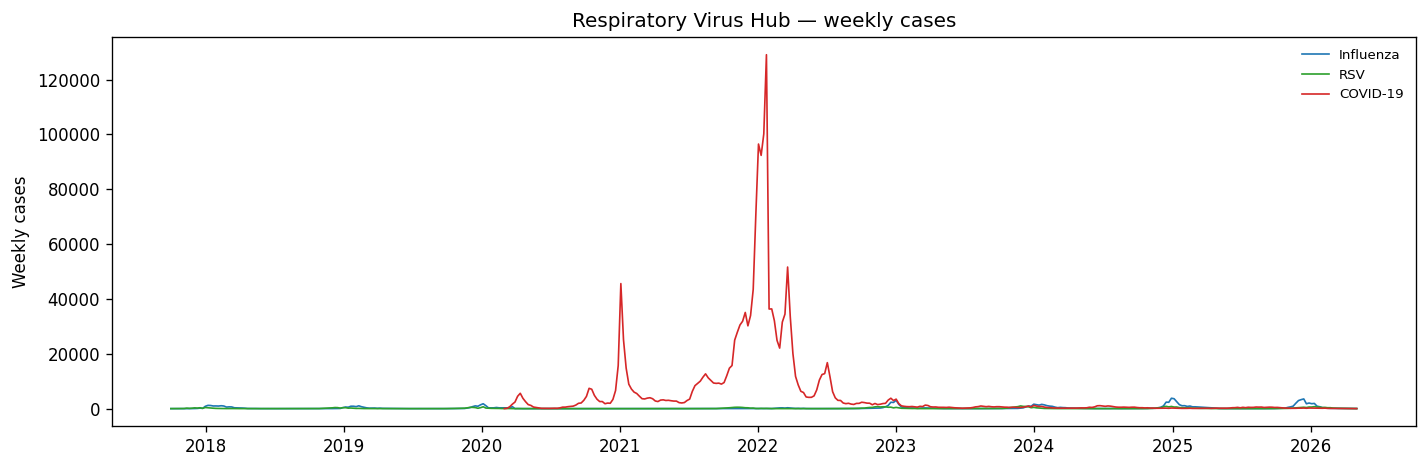

In [50]:
DISEASE_COLOR = {
    "Influenza": "#1f77b4",
    "RSV":       "#2ca02c",
    "COVID-19":  "#d62728",
}

fig, ax = plt.subplots(figsize=(12, 4), dpi=120)
for disease, color in DISEASE_COLOR.items():
    s = df[df["disease"] == disease]
    ax.plot(s["week_start"], s["weekly_cases"], color=color, linewidth=1.0, label=disease)
ax.set_ylabel("Weekly cases")
ax.set_title("Respiratory Virus Hub — weekly cases")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Distribution of raw weekly cases

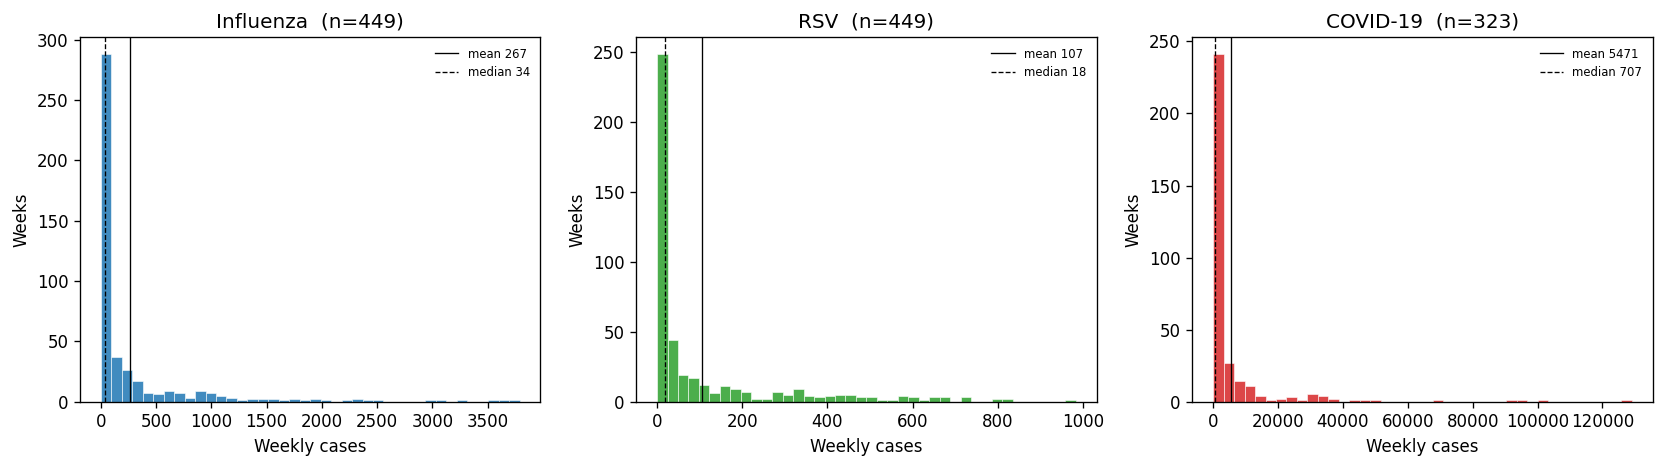

,count,mean,std,min,25%,50%,75%,max
disease,,,,,,,,
COVID-19,323.0,5471.328173,14406.430794,15.0,224.0,707.0,3393.0,129075.0
Influenza,449.0,267.481069,564.522578,0.0,5.0,34.0,225.0,3790.0
RSV,449.0,106.681514,181.793996,0.0,3.0,18.0,113.0,983.0


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), dpi=120)
for ax, (disease, color) in zip(axes, DISEASE_COLOR.items()):
    s = df[df["disease"] == disease]["weekly_cases"].dropna()
    ax.hist(s, bins=40, color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.axvline(s.mean(),   color="black", linestyle="-",  linewidth=0.8, label=f"mean {s.mean():.0f}")
    ax.axvline(s.median(), color="black", linestyle="--", linewidth=0.8, label=f"median {s.median():.0f}")
    ax.set_title(f"{disease}  (n={len(s)})")
    ax.set_xlabel("Weekly cases")
    ax.set_ylabel("Weeks")
    ax.legend(fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

df.groupby("disease")["weekly_cases"].describe()[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

## PSD — single disease

Influenza: 449 weeks


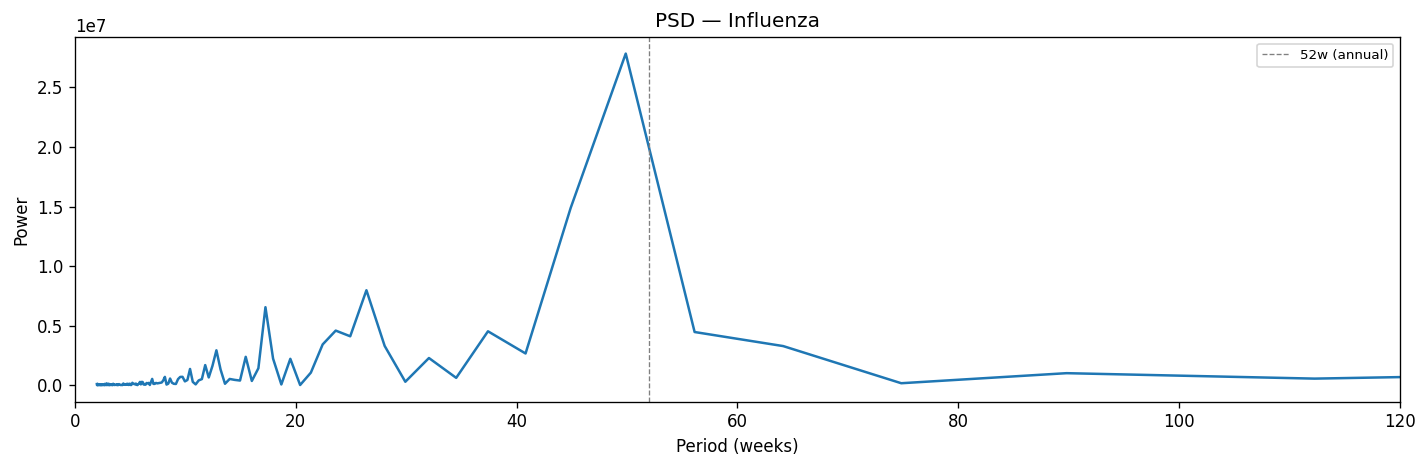

In [52]:
DISEASE = "Influenza"
series = df[df["disease"] == DISEASE].sort_values("week_start")["weekly_cases"].reset_index(drop=True)
print(f"{DISEASE}: {len(series)} weeks")

fig, ax = plt.subplots(figsize=(12, 4), dpi=120)
freqs, power = periodogram(series.dropna(), fs=1.0, detrend="linear")
periods = 1 / freqs[1:]
ax.plot(periods, power[1:])
ax.set_xlabel("Period (weeks)")
ax.set_ylabel("Power")
ax.set_title(f"PSD \u2014 {DISEASE}")
ax.set_xlim(0, 120)
ax.axvline(52, color="grey", linestyle="--", linewidth=0.8, label="52w (annual)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## PSD — all three diseases overlaid

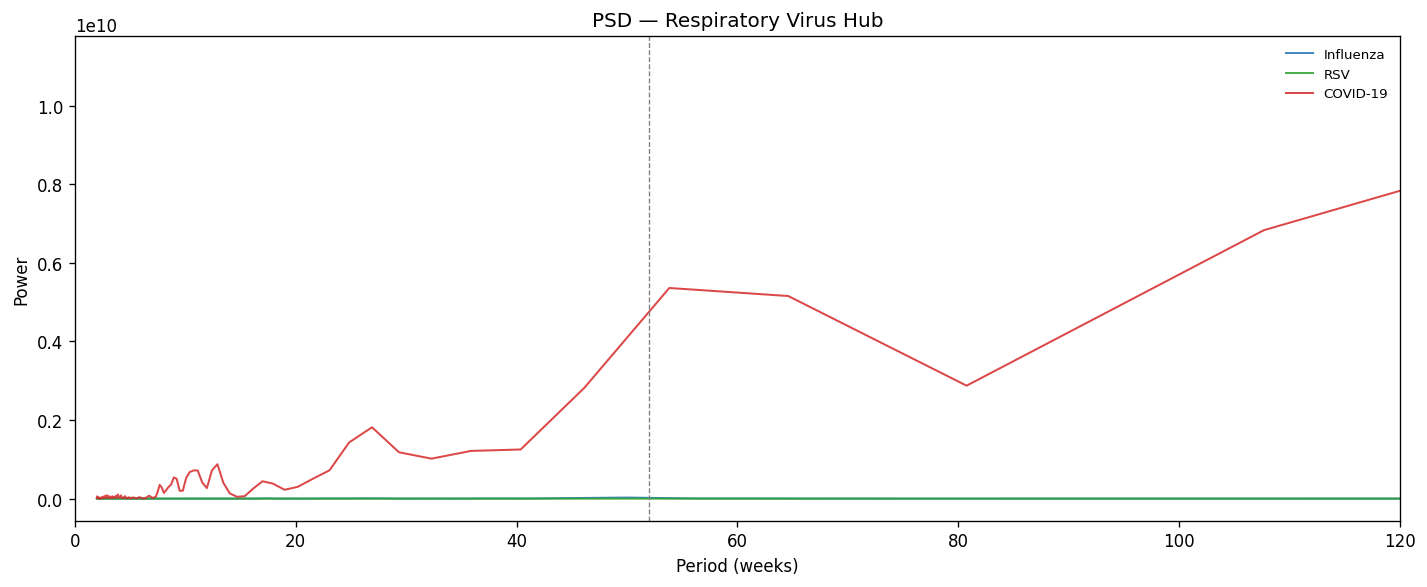

In [53]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=120)
for disease, color in DISEASE_COLOR.items():
    s = df[df["disease"] == disease].sort_values("week_start")["weekly_cases"].dropna()
    freqs, power = periodogram(s, fs=1.0, detrend="linear")
    periods = 1 / freqs[1:]
    ax.plot(periods, power[1:], color=color, linewidth=1.2, alpha=0.85, label=disease)

ax.set_xlim(0, 120)
ax.set_xlabel("Period (weeks)")
ax.set_ylabel("Power")
ax.set_title("PSD \u2014 Respiratory Virus Hub")
ax.axvline(52, color="grey", linestyle="--", linewidth=0.8)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Dominant periods (top 5 by power, excluding DC)

In [54]:
rows = []
for disease in DISEASE_COLOR:
    s = df[df["disease"] == disease].sort_values("week_start")["weekly_cases"].dropna()
    freqs, power = periodogram(s, fs=1.0, detrend="linear")
    order = np.argsort(power[1:])[::-1][:5]
    for rank, idx in enumerate(order, start=1):
        rows.append({
            "disease": disease,
            "rank": rank,
            "period_weeks": round(1 / freqs[1:][idx], 2),
            "power": power[1:][idx],
        })
pd.DataFrame(rows)

,disease,rank,period_weeks,power
0,Influenza,1,49.89,2.784470e+07
1,Influenza,2,44.90,1.486861e+07
2,Influenza,3,26.41,7.967779e+06
3,Influenza,4,449.00,6.776833e+06
4,Influenza,5,17.27,6.542658e+06
5,RSV,1,49.89,2.832515e+06
6,RSV,2,56.12,2.361713e+06
7,RSV,3,26.41,1.898519e+06
8,RSV,4,28.06,1.504120e+06
9,RSV,5,64.14,1.392918e+06


## ACF for reference

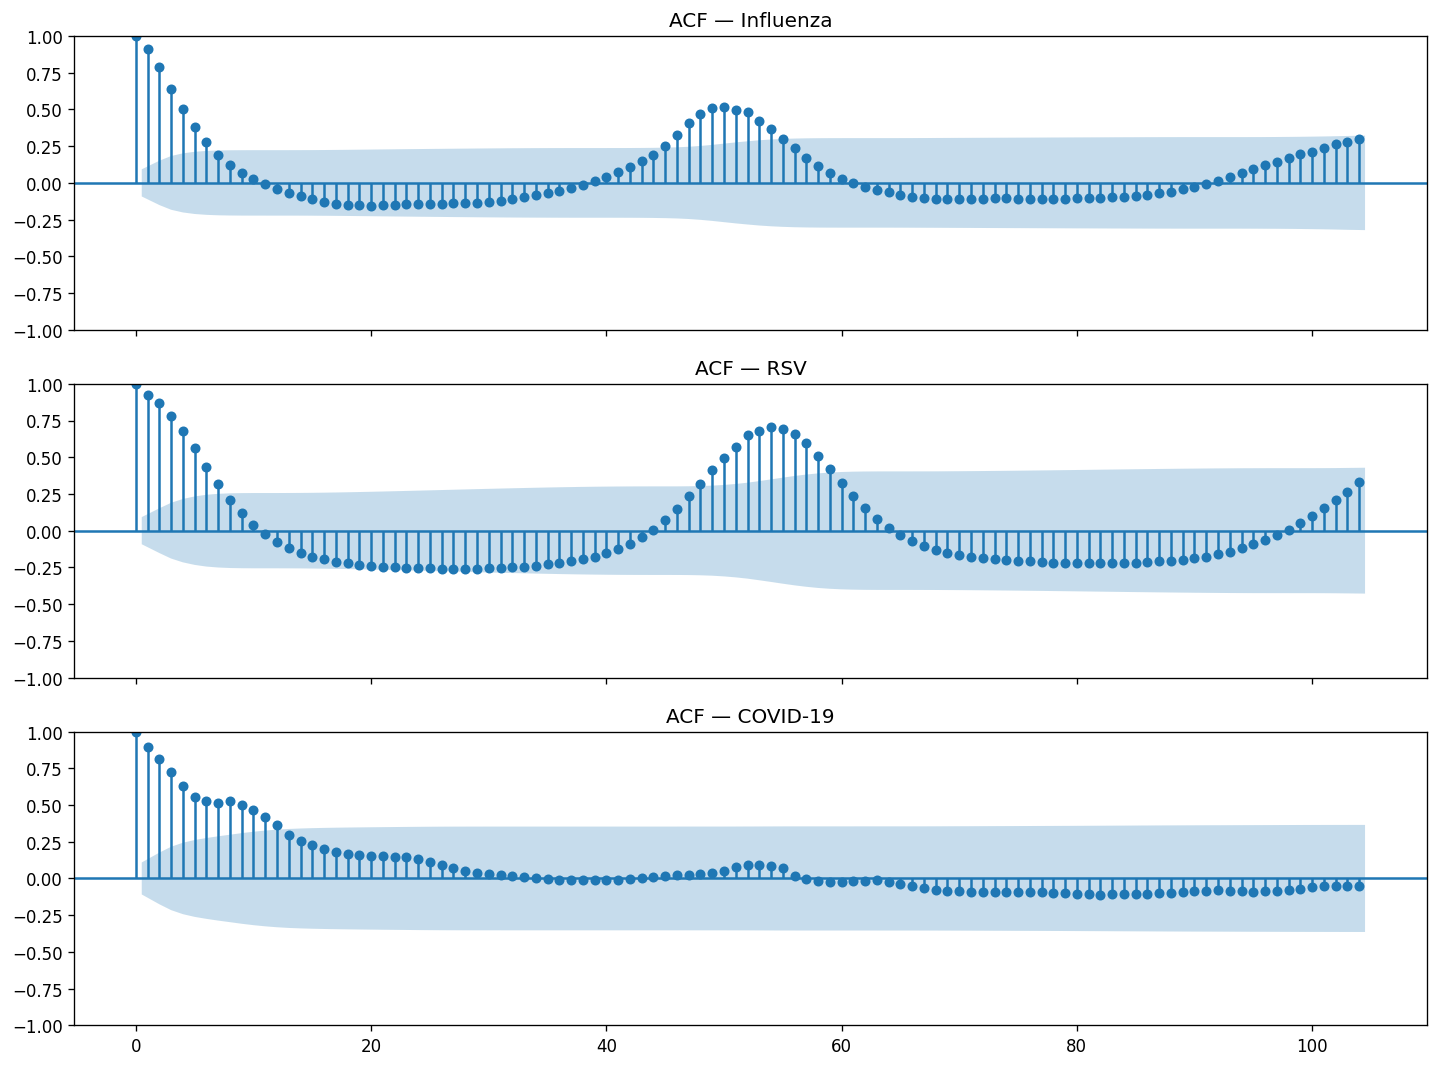

In [55]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), dpi=120, sharex=True)
for ax, disease in zip(axes, DISEASE_COLOR):
    s = df[df["disease"] == disease].sort_values("week_start")["weekly_cases"].dropna()
    plot_acf(s, lags=min(104, len(s) - 1), ax=ax, title=f"ACF \u2014 {disease}")
plt.tight_layout()
plt.show()

## PACF for reference

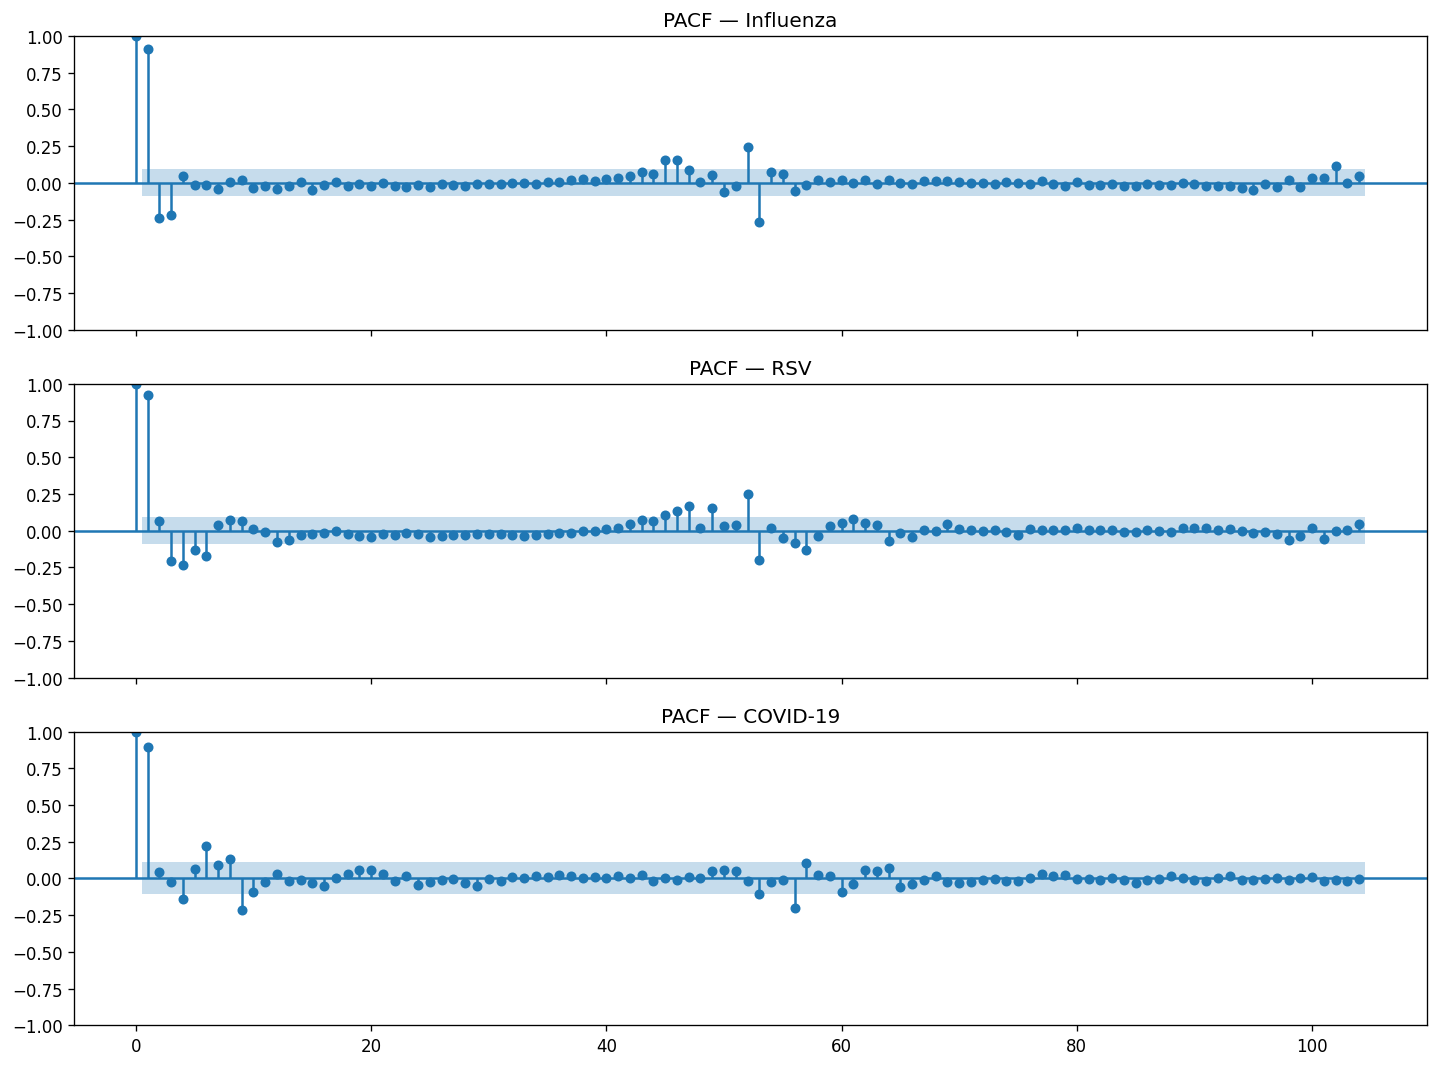

In [56]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, axes = plt.subplots(3, 1, figsize=(12, 9), dpi=120, sharex=True)
for ax, disease in zip(axes, DISEASE_COLOR):
    s = df[df["disease"] == disease].sort_values("week_start")["weekly_cases"].dropna()
    lags = min(104, len(s) // 2 - 1)
    plot_pacf(s, lags=lags, ax=ax, method="ywm", title=f"PACF — {disease}")
plt.tight_layout()
plt.show()

## PyJAGS — Poisson baseline + AR(1) + annual cycle

Same chain/burn-in defaults as the trolley models: `chains=4, burnin=10000, sample=20000, adapt=1000`.

**Structure (log-link Poisson with AR(1) on log-residuals):**

- `y[t] ~ Poisson(λ[t])`
- `log λ[t] = μ[t] + φ · (log(y[t-1] + 0.5) − μ[t-1])`, with `log λ[1] = μ[1]`
- `μ[t] = α + β·cos(2π t/52) + γ·sin(2π t/52)`
- Vague normal priors on α, β, γ; `φ ~ Uniform(−1, 1)`. No `tau` (Poisson variance is fixed by the mean).

Phase = `arctan2(γ, β)` exactly as in `pyjags_pipeline.significance.compute_phase` — the harmonic
lives in the log-rate so the formula is unchanged.

**Caveat:** strict Poisson assumes Var = Mean. Outbreak weeks almost always overdisperse; if the
fitted `fullmod` vs `y` residuals look fat-tailed, the next step is Negative-Binomial
(`dnegbin(p, r)` with `p = r/(r+λ)`).

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pyjags
from pyjags_pipeline.fitting import fit_jags, compute_gelman, flatten_samples
from pyjags_pipeline.diagnostics import trace_with_dist
from pyjags_pipeline.significance import compute_phase

DISEASE    = "Influenza"                       # change to "RSV" or "COVID-19" to refit
PERIOD     = 52                                # weeks per year
START_DATE = pd.Timestamp("2023-01-01", tz="UTC")   # match trolley span
                                                    # set to None to use full flu history

JAGS_MODEL = """
model{
  for(i in 1:I){
    log_lambda[i,1] <- mu[i,1]
    y[i,1] ~ dpois(exp(log_lambda[i,1]))
    for(t in 2:T){
      log_lambda[i,t] <- mu[i,t] + phi * (log(y[i,t-1] + 0.5) - mu[i,t-1])
      y[i,t] ~ dpois(exp(log_lambda[i,t]))
    }
    for(t in 1:T){
      mu[i,t] <- alpha[i] +
                 beta[i]  * cos((2 * pi) * (t/52)) +
                 gamma[i] * sin((2 * pi) * (t/52))
    }
    fullmod[i,1] <- exp(mu[i,1])
    for(t in 2:T){
      fullmod[i,t] <- exp(log_lambda[i,t])
    }
    for(t in 1:T){
      resid[i,t] <- y[i,t] - fullmod[i,t]
    }
    alpha[i] ~ dnorm(0, 0.001)
    beta[i]  ~ dnorm(0, 0.001)
    gamma[i] ~ dnorm(0, 0.001)
  }
  phi ~ dunif(-1, 1)
}
"""

sub = df[df["disease"] == DISEASE].sort_values("week_start").copy()
if START_DATE is not None:
    sub = sub[sub["week_start"] >= START_DATE]

series = sub["weekly_cases"].dropna().reset_index(drop=True).astype(int)
y = series.values.reshape(1, -1)               # shape (I=1, T)
T = y.shape[1]

data_dict = dict(y=y, I=1, T=T, pi=np.pi)
monitor   = ["alpha", "beta", "gamma", "phi", "mu", "fullmod", "resid"]

print(f"{DISEASE}: T = {T} weeks  "
      f"({sub['week_start'].min().date()} to {sub['week_start'].max().date()})")
samples, model = fit_jags(
    JAGS_MODEL, data_dict, monitor,
    chains=4, burnin=10000, sample=20000, adapt=1000, seed=42,
)
print("Sampling complete.")

### Gelman-Rubin diagnostic

Same `compute_gelman` helper as the pipeline (ArviZ R-hat). Drop the 2-D `mu`/`fullmod`/`resid`
nodes first — they break the scalar-only flattening, exactly as in `BaseModel.fit`.

In [58]:
scalar_samples = {k: v for k, v in samples.items()
                  if k not in ("mu", "fullmod", "resid")}

gelman = compute_gelman(scalar_samples)
raw    = flatten_samples(scalar_samples, n_chains=4)

# flatten_samples collapses single-element vector params to bare names ('beta'),
# but compute_phase + downstream code expect 'beta[1]' etc.
raw = raw.rename(columns={"alpha": "alpha[1]",
                          "beta":  "beta[1]",
                          "gamma": "gamma[1]"})

print("Max R-hat:", gelman["Point est."].max())
gelman

Max R-hat: 1.001493932490367


,param,Point est.,Upper C.I.
0,beta,1.001230,1.001230
1,gamma,1.000583,1.000583
2,alpha,1.001494,1.001494
3,phi,1.000070,1.000070


### Trace plots

Same `trace_with_dist` helper as the pipeline diagnostics — trace + LOWESS on the left,
per-chain rotated KDE on the right.

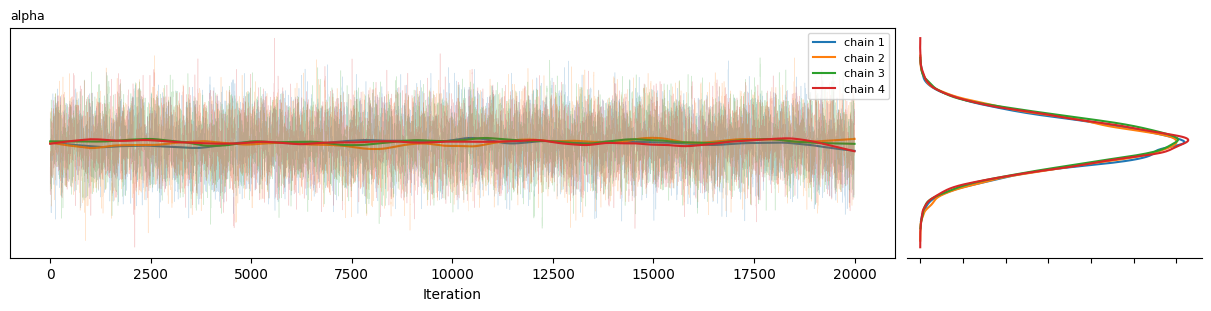

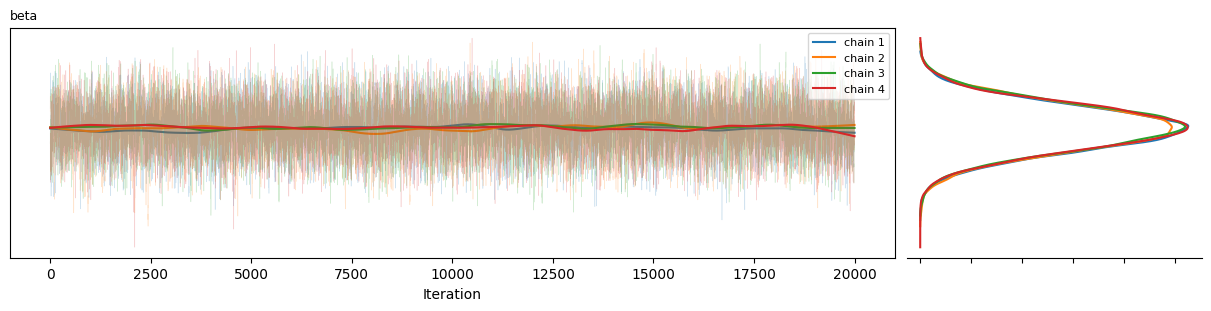

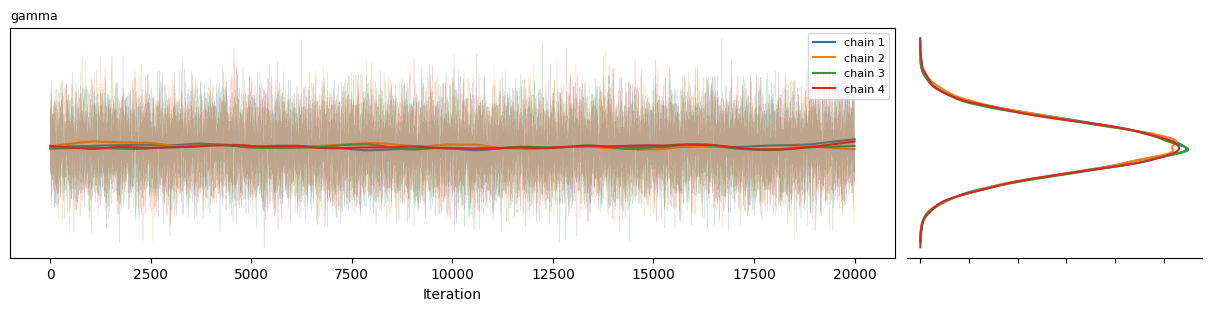

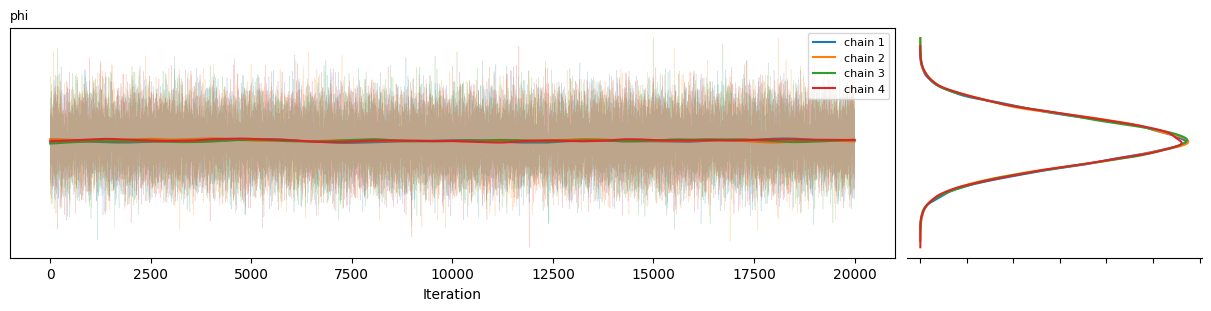

In [59]:
trace_vars = ["alpha", "beta", "gamma", "phi"]
trace_with_dist(scalar_samples, trace_vars)

### Phase + 95% credible interval

Peak week = `((52 / 2π) · arctan2(γ, β)) mod 52` — same formula as
`pyjags_pipeline.significance.compute_phase`. CI is a **circular** highest-posterior-density
interval (shortest arc containing 95% of posterior mass), reported in signed weeks from week 0
to match how the trolley tables are formatted.

In [ ]:
def circular_mean(samples, period=PERIOD):
    rad = 2 * np.pi * samples / period
    mean_rad = np.arctan2(np.mean(np.sin(rad)), np.mean(np.cos(rad)))
    return (period * mean_rad / (2 * np.pi)) % period

def circular_hpd(samples, prob=0.95, period=PERIOD):
    s = np.sort(samples)
    n = len(s)
    k = int(np.ceil(prob * n))
    extended = np.concatenate([s, s + period])
    arcs = extended[k - 1:k - 1 + n] - extended[:n]
    i = int(np.argmin(arcs))
    return s[i], extended[i + k - 1] % period

def signed_wk(w, period=PERIOD):
    """Map week 0..period to signed weeks from NY in (-period/2, +period/2]."""
    return w if w <= period / 2 else w - period

# --- shift posterior so 0 = New Year (Jan 1) ---
# Use the *filtered* series start (set by START_DATE in the fit cell), not full-history min.
first_week_floor = sub["week_start"].min()
ny_ref = pd.Timestamp(year=first_week_floor.year + (0 if first_week_floor.month == 1 and first_week_floor.day == 1 else 1),
                      month=1, day=1, tz=first_week_floor.tz)
# If the series itself starts at or just after Jan 1, use that year's NY (t_ny ~ 0..1)
if first_week_floor <= pd.Timestamp(year=first_week_floor.year, month=1, day=7, tz=first_week_floor.tz):
    ny_ref = pd.Timestamp(year=first_week_floor.year, month=1, day=1, tz=first_week_floor.tz)
t_ny = (ny_ref - first_week_floor).days / 7 + 1
print(f"Series start: {first_week_floor.date()}  →  NY at t = {t_ny:.3f}")

phases = compute_phase(raw, [DISEASE])
peak_series_t = phases[DISEASE]                          # series-index space
peak_from_ny  = (peak_series_t - t_ny) % PERIOD          # weeks since NY, in [0, 52)

mean_w         = circular_mean(peak_from_ny)
hpd_lo, hpd_hi = circular_hpd(peak_from_ny, prob=0.95)
arc_width      = (hpd_hi - hpd_lo) % PERIOD

print(f"{DISEASE} peak — weeks from New Year (0 = Jan 1)")
print(f"  posterior mean:    {mean_w:.2f}  (signed: {signed_wk(mean_w):+.2f})")
print(f"  95% circular HPD:  [{hpd_lo:.2f}, {hpd_hi:.2f}]"
      f"  (signed: [{signed_wk(hpd_lo):+.2f}, {signed_wk(hpd_hi):+.2f}])")
print(f"  HPD arc width:     {arc_width:.2f} wk")

### Annual cycle

Posterior of the harmonic component on the **rate scale** — `exp(α + β·cos(2π t/52) + γ·sin(2π t/52))`,
i.e. the seasonal expected case count, ignoring AR(1) and observation noise. Mean ± 95% pointwise
credible band over a single 52-week cycle, with a vertical line at the posterior-mean peak.

In [ ]:
alpha_s = raw["alpha[1]"].values
beta_s  = raw["beta[1]"].values
gamma_s = raw["gamma[1]"].values

# x-axis: weeks from New Year, 0..52. Convert to series-index t via t = x + t_ny.
x_grid = np.arange(0, PERIOD + 1)               # 0..52, weeks from NY
t_grid = x_grid + t_ny
omega  = 2 * np.pi * t_grid / PERIOD            # (53,)

cycle_log = (alpha_s[:, None]
             + beta_s[:, None]  * np.cos(omega)[None, :]
             + gamma_s[:, None] * np.sin(omega)[None, :])
cycle = np.exp(cycle_log)

cycle_mean = cycle.mean(axis=0)
cycle_lo   = np.quantile(cycle, 0.025, axis=0)
cycle_hi   = np.quantile(cycle, 0.975, axis=0)

fig, ax = plt.subplots(figsize=(12, 4), dpi=120)
ax.fill_between(x_grid, cycle_lo, cycle_hi, alpha=0.25,
                color=DISEASE_COLOR[DISEASE], label="95% CI")
ax.plot(x_grid, cycle_mean, color=DISEASE_COLOR[DISEASE],
        linewidth=1.6, label="posterior mean")
ax.axvline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.6, label="New Year (wk 0)")
ax.axvline(mean_w, color="grey", linestyle="--", linewidth=0.9,
           label=f"peak (wk {mean_w:.1f} from NY)")
ax.set_xlabel("Weeks from New Year")
ax.set_ylabel("Expected cases (rate scale)")
ax.set_title(f"Annual cycle — {DISEASE}")
ax.set_xlim(0, PERIOD)
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

## Trolley vs influenza — phase difference (posterior subtraction)

Treat the two MCMC runs as independent posteriors. For each HSE region, pair posterior samples
of the **trolley** phase with samples of the **influenza** phase (both expressed as weeks from
New Year), then compute the **circular signed difference**:

`diff = (trolley_peak − flu_peak + 26) mod 52 − 26`   → in (−26, +26]

Positive diff = trolley peaks **after** flu, negative = before.

This is the direct Bayesian version of the question "does the trolley peak align with flu?":
the 95% credible interval of `diff` either contains 0 (consistent) or it does not. No window
threshold to pick.

In [ ]:
TROLLEY_VERSION = "v2.6"
TROLLEY_DATA    = "data/wide_weekly_scaledPer10k.csv"
RNG_SEED        = 42

# --- load trolley raw samples + region order ---
trolley_csv = pd.read_csv(f"../{TROLLEY_DATA}")
trolley_regions = trolley_csv["Region"].tolist()
trolley_first_date = pd.to_datetime(trolley_csv.columns[1], utc=True)

trolley_raw = pd.read_csv(
    f"../data/models/wide_weekly_scaledPer10k/{TROLLEY_VERSION}/raw_samples.csv"
)

# t_ny in the trolley series-index (first column is t=1)
ny_ref_trolley = pd.Timestamp(year=trolley_first_date.year, month=1, day=1,
                              tz=trolley_first_date.tz)
t_ny_trolley = (ny_ref_trolley - trolley_first_date).days / 7 + 1
print(f"Trolley series starts: {trolley_first_date.date()} (t=1), "
      f"NY at t = {t_ny_trolley:.3f}")

# --- per-region trolley phase, shifted to weeks-from-NY ---
trolley_phases_ny = {}
for i, region in enumerate(trolley_regions, start=1):
    b = trolley_raw[f"beta[{i}]"].values
    g = trolley_raw[f"gamma[{i}]"].values
    peak_t = ((PERIOD / (2 * np.pi)) * np.arctan2(g, b)) % PERIOD
    trolley_phases_ny[region] = (peak_t - t_ny_trolley) % PERIOD

# --- pair with flu posterior and compute signed circular difference ---
rng = np.random.default_rng(RNG_SEED)
flu_samples_ny = peak_from_ny.copy()

rows = []
for region, trolley_samples_ny in trolley_phases_ny.items():
    n = min(len(trolley_samples_ny), len(flu_samples_ny))
    t_s = rng.choice(trolley_samples_ny, size=n, replace=False)
    f_s = rng.choice(flu_samples_ny,    size=n, replace=False)

    diff = (t_s - f_s + PERIOD / 2) % PERIOD - PERIOD / 2   # (-26, +26]

    mean_d = float(np.mean(diff))
    lo, hi = np.quantile(diff, [0.025, 0.975])
    p_consistent = float(np.mean((diff >= lo) & (diff <= hi) & (lo <= 0 <= hi)))
    # cleaner: probability mass on each side of 0
    p_pos = float(np.mean(diff > 0))

    rows.append({
        "Region":           region,
        "trolley peak (wk from NY)": float(np.mean(trolley_samples_ny)),
        "flu peak (wk from NY)":     float(np.mean(flu_samples_ny)),
        "diff mean (wk)":   mean_d,
        "95% CI":           f"[{lo:+.2f}, {hi:+.2f}]",
        "Contains 0":       "Yes" if lo <= 0 <= hi else "No",
        "P(trolley after flu)": p_pos,
    })

diff_df = (pd.DataFrame(rows)
           .sort_values("diff mean (wk)")
           .reset_index(drop=True))
diff_df

## Trolley vs fixed flu window — P(peak ∈ [NY+2wk ± 8wk])

Fixed window (no flu posterior used):

- **Centre:** 2 weeks after New Year
- **Width:** ±8 weeks (≈ ±2 months; clean integer)
- **Window (weeks from NY):** [−6, +10] → roughly ISO wk 47 → ISO wk 10 → mid-Nov to mid-March

For each region, count the posterior fraction of trolley-peak samples falling inside that
window (circular). Higher = the trolley peak is more strongly aligned with the flu season.

In [ ]:
CENTER_WK  = 2          # weeks after NY
HALF_WIDTH = 8          # ±8 wk ≈ ±~2 months (total window = 16 wk)

P_COL = f"P(peak ∈ [{CENTER_WK-HALF_WIDTH:+d}, {CENTER_WK+HALF_WIDTH:+d}] wk)"

def in_circular_window(samples, center, half_width, period=PERIOD):
    """Posterior mass inside [center - half_width, center + half_width] mod period."""
    d = (samples - center + period / 2) % period - period / 2   # signed dist to centre
    return float(np.mean(np.abs(d) <= half_width))

rows = []
for region, peak_ny in trolley_phases_ny.items():
    rows.append({
        "Region":                    region,
        "Trolley peak (wk from NY)": float(circular_mean(peak_ny)),
        P_COL:                       in_circular_window(peak_ny, CENTER_WK, HALF_WIDTH),
    })

window_df = (pd.DataFrame(rows)
             .sort_values(P_COL, ascending=False)
             .reset_index(drop=True))
window_df

### Same window — tighter ±4 wk (≈ ±1 month)

Same idea, narrower window: **2 weeks after NY ± 1 month** → `[−2, +6]` wk from NY
(≈ ISO wk 51 → ISO wk 6 → mid-Dec to mid-Feb). Stricter test of alignment with the
flu peak.

In [ ]:
CENTER_WK_NARROW  = 2
HALF_WIDTH_NARROW = 4

P_COL_NARROW = f"P(peak ∈ [{CENTER_WK_NARROW-HALF_WIDTH_NARROW:+d}, {CENTER_WK_NARROW+HALF_WIDTH_NARROW:+d}] wk)"

rows = []
for region, peak_ny in trolley_phases_ny.items():
    rows.append({
        "Region":                    region,
        "Trolley peak (wk from NY)": float(circular_mean(peak_ny)),
        P_COL_NARROW:                in_circular_window(peak_ny, CENTER_WK_NARROW, HALF_WIDTH_NARROW),
    })

window_df_narrow = (pd.DataFrame(rows)
                    .sort_values(P_COL_NARROW, ascending=False)
                    .reset_index(drop=True))
window_df_narrow

### Trolley peak — 95% circular HPD per region

Same HPD definition as the flu cell: shortest arc on the 52-week circle containing 95% of
posterior mass. Reported as weeks-from-NY (signed, where negative = before NY).

In [65]:
def format_arc_ci(lo, hi, period=PERIOD):
    """Format a circular HPD as signed weeks from NY, handling wrap through 0."""
    if lo > hi:                              # wraps through NY
        return f"[{lo - period:+.2f}, {hi:+.2f}]"
    return f"[{signed_wk(lo):+.2f}, {signed_wk(hi):+.2f}]"

rows = []
for region, peak_ny in trolley_phases_ny.items():
    mean_w   = circular_mean(peak_ny)
    lo, hi   = circular_hpd(peak_ny, prob=0.95)
    width    = (hi - lo) % PERIOD
    rows.append({
        "Region":              region,
        "Mean (wk from NY)":   signed_wk(mean_w),
        "95% CI (wk from NY)": format_arc_ci(lo, hi),
        "Width (wk)":          width,
    })

ci_df = (pd.DataFrame(rows)
         .sort_values("Mean (wk from NY)")
         .reset_index(drop=True))
ci_df

,Region,Mean (wk from NY),95% CI (wk from NY),Width (wk)
0,HSE Dublin and North East,0.782588,"[-3.48, +4.94]",8.426592
1,HSE Dublin and South East,1.105336,"[-3.36, +5.85]",9.208857
2,HSE South West,1.689305,"[-3.45, +6.88]",10.326761
3,HSE West and North West,4.529872,"[-8.60, +18.75]",27.352238
4,HSE Dublin and Midlands,4.829743,"[-0.69, +10.27]",10.959737
5,HSE Mid West,18.111500,"[-3.42, +40.14]",43.559844


### P(trolley peak ∈ flu 95% HPD)

Window = the **95% circular HPD of the influenza phase posterior** (from the phase cell above:
`[hpd_lo, hpd_hi]` in weeks-from-NY). For each region, report the fraction of trolley peak
posterior samples falling inside that arc.

This is more principled than the fixed ±2-month window because the window itself comes from the
flu posterior, not a clinical guess.

**Caveat:** because the flu Poisson likelihood under-disperses, that 95% HPD is **artificially
narrow** — the probabilities here will be biased *low*. Treat as a stress-test: any region with
P > 0.5 here is solidly inside the flu window.

In [ ]:
def in_circular_arc(samples, lo, hi, period=PERIOD):
    """Fraction of samples inside the arc [lo, hi] on the circle (wraps through 0 if lo > hi)."""
    s = samples % period
    if lo <= hi:
        return float(np.mean((s >= lo) & (s <= hi)))
    return float(np.mean((s >= lo) | (s <= hi)))     # wraps through 0

P_COL = f"P(peak ∈ flu 95% HPD [{signed_wk(hpd_lo):+.2f}, {signed_wk(hpd_hi):+.2f}] wk)"

rows = []
for region, peak_ny in trolley_phases_ny.items():
    rows.append({
        "Region":                    region,
        "Trolley peak (wk from NY)": signed_wk(circular_mean(peak_ny)),
        P_COL:                       in_circular_arc(peak_ny, hpd_lo, hpd_hi),
    })

flu_hpd_df = (pd.DataFrame(rows)
              .sort_values(P_COL, ascending=False)
              .reset_index(drop=True))

print(f"Flu 95% HPD width: {(hpd_hi - hpd_lo) % PERIOD:.2f} wk")
flu_hpd_df